In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import time

In [6]:
# Graph q
q = nx.Graph()
q.add_node('v1', label='A')
q.add_node('v2', label='A')
q.add_node('v3', label='A')
q.add_node('v4', label='A')
q.add_edge('v1', 'v2', label='b')
q.add_edge('v1', 'v3', label='a')
q.add_edge('v2', 'v4', label='a')

# Graph g
g = nx.Graph()
g.add_node('u1', label='A')
g.add_node('u2', label='B')
g.add_node('u3', label='A')
g.add_node('u4', label='A')
g.add_edge('u1', 'u2', label='b')
g.add_edge('u2', 'u4', label='a')
g.add_edge('u1', 'u3', label='a')

print("Graph q:", q.nodes(data=True), q.edges(data=True))
print("Graph g:", g.nodes(data=True), g.edges(data=True))

Graph q: [('v1', {'label': 'A'}), ('v2', {'label': 'A'}), ('v3', {'label': 'A'}), ('v4', {'label': 'A'})] [('v1', 'v2', {'label': 'b'}), ('v1', 'v3', {'label': 'a'}), ('v2', 'v4', {'label': 'a'})]
Graph g: [('u1', {'label': 'A'}), ('u2', {'label': 'B'}), ('u3', {'label': 'A'}), ('u4', {'label': 'A'})] [('u1', 'u2', {'label': 'b'}), ('u1', 'u3', {'label': 'a'}), ('u2', 'u4', {'label': 'a'})]


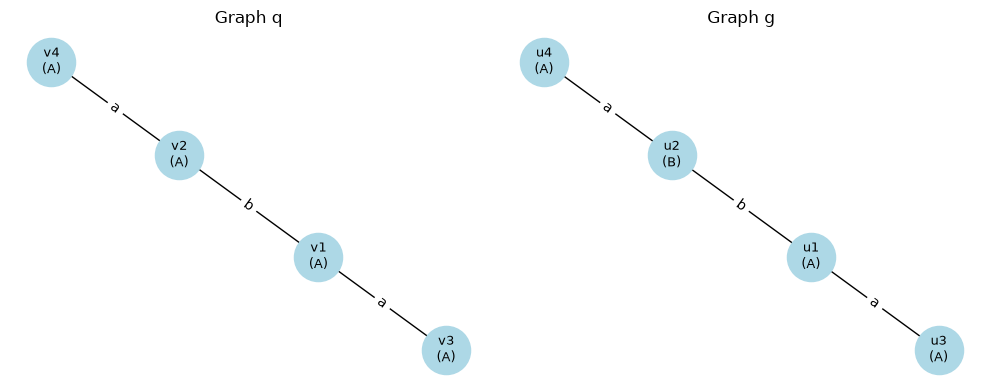

In [7]:
def draw_graph(G, ax, title):
    pos = nx.spring_layout(G, seed=42)
    node_labels = nx.get_node_attributes(G, 'label')
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw(G, pos, ax=ax, with_labels=True, labels={n: f"{n}\n({l})" for n, l in node_labels.items()},
            node_color='lightblue', node_size=1200, font_size=9)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_graph(q, axes[0], "Graph q")
draw_graph(g, axes[1], "Graph g")
plt.tight_layout()
plt.show()

In [9]:
def node_match(n1, n2):
    return n1['label'] == n2['label']

def edge_match(e1, e2):
    return e1['label'] == e2['label']

ged = nx.graph_edit_distance(q, g, node_match=node_match, edge_match=edge_match)
print(f"GED(q, g) = {ged}")

# Sanity check: our computed GED should never exceed the paper's illustrative upper bound of 3,
# since GED is a minimum and their sequence is just one valid (but possibly suboptimal) example.
assert ged <= 3, f"GED should be <= the paper's upper-bound example of 3, got {ged}"
print(f"Within the paper's upper bound (<= 3) \u2713")

# In this case the true minimum turns out to be 1: graph g is structurally identical to q
# (same edges, same edge labels) with only node u2's label differing from v2 (B vs A).
# So a single relabel operation suffices -- the paper's 3-step sequence was valid but not optimal.

GED(q, g) = 1.0
Within the paper's upper bound (<= 3) ✓


In [10]:
import math

def compute_ged(G1, G2):
    return nx.graph_edit_distance(G1, G2, node_match=node_match, edge_match=edge_match)

def normalized_ged(G1, G2, raw_ged=None):
    if raw_ged is None:
        raw_ged = compute_ged(G1, G2)
    avg_size = (G1.number_of_nodes() + G2.number_of_nodes()) / 2
    return raw_ged / avg_size

def similarity_score(G1, G2, raw_ged=None):
    nged = normalized_ged(G1, G2, raw_ged)
    return math.exp(-nged)

nged_qg = normalized_ged(q, g, raw_ged=ged)
sim_qg = similarity_score(q, g, raw_ged=ged)
print(f"nGED(q, g) = {nged_qg:.4f}")
print(f"S(q, g) = {sim_qg:.4f}")

nGED(q, g) = 0.2500
S(q, g) = 0.7788


In [11]:
def make_graph(nodes, edges):
    """nodes: list of (id, label). edges: list of (u, v, label)"""
    G = nx.Graph()
    for nid, label in nodes:
        G.add_node(nid, label=label)
    for u, v, label in edges:
        G.add_edge(u, v, label=label)
    return G

# Query graph - reuse q from before
query = q

database = {
    "g_near_dup": g,  # 3 edits from q (per Fig 6)
    "g_identical": make_graph(
        [('v1','A'),('v2','A'),('v3','A'),('v4','A')],
        [('v1','v2','b'), ('v1','v3','a'), ('v2','v4','a')]
    ),  # identical to q
    "g_one_edit": make_graph(
        [('v1','A'),('v2','A'),('v3','A'),('v4','A')],
        [('v1','v2','a'), ('v1','v3','a'), ('v2','v4','a')]  # just relabeled one edge
    ),
    "g_very_different": make_graph(
        [('x1','A'),('x2','B'),('x3','A'),('x4','B'),('x5','A')],
        [('x1','x2','a'), ('x2','x3','b'), ('x3','x4','a'), ('x4','x5','b'), ('x1','x5','a')]
    ),
    "g_bigger": make_graph(
        [('y1','A'),('y2','A'),('y3','A'),('y4','A'),('y5','A'),('y6','A')],
        [('y1','y2','a'), ('y2','y3','b'), ('y3','y4','a'), ('y4','y5','b'), ('y5','y6','a'), ('y1','y6','b')]
    ),
}

print(f"Database has {len(database)} graphs")
for name, G in database.items():
    print(f"  {name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Database has 5 graphs
  g_near_dup: 4 nodes, 3 edges
  g_identical: 4 nodes, 3 edges
  g_one_edit: 4 nodes, 3 edges
  g_very_different: 5 nodes, 5 edges
  g_bigger: 6 nodes, 6 edges


In [12]:
results = []
for name, G in database.items():
    raw_ged = compute_ged(query, G)
    sim = similarity_score(query, G, raw_ged=raw_ged)
    results.append((name, raw_ged, sim))

# Sort by similarity score, descending (most similar first)
results.sort(key=lambda x: x[2], reverse=True)

print(f"{'Rank':<5}{'Graph':<20}{'GED':<8}{'Similarity':<10}")
print("-" * 43)
for rank, (name, raw_ged, sim) in enumerate(results, 1):
    print(f"{rank:<5}{name:<20}{raw_ged:<8}{sim:.4f}")

Rank Graph               GED     Similarity
-------------------------------------------
1    g_identical         0.0     1.0000
2    g_near_dup          1.0     0.7788
3    g_one_edit          1.0     0.7788
4    g_very_different    4.0     0.4111
5    g_bigger            5.0     0.3679


n=4 nodes: 0.001s
n=6 nodes: 0.012s
n=8 nodes: 0.637s
n=10 nodes: 10.001s
n=12 nodes: 10.001s


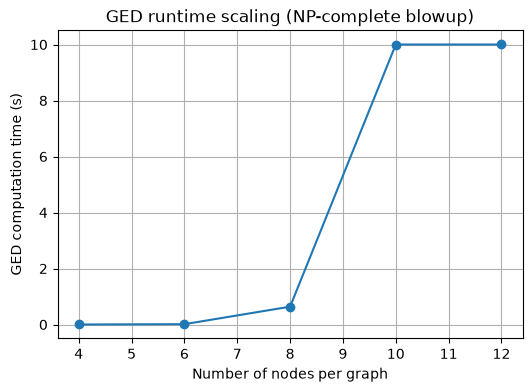

In [13]:
import random

def random_graph(n_nodes, labels=['A', 'B'], edge_prob=0.4, seed=None):
    rng = random.Random(seed)
    G = nx.Graph()
    for i in range(n_nodes):
        G.add_node(i, label=rng.choice(labels))
    for i, j in itertools.combinations(range(n_nodes), 2):
        if rng.random() < edge_prob:
            G.add_edge(i, j, label=rng.choice(['a', 'b']))
    return G

sizes = [4, 6, 8, 10, 12]
times = []

for n in sizes:
    G1 = random_graph(n, seed=1)
    G2 = random_graph(n, seed=2)
    start = time.time()
    nx.graph_edit_distance(G1, G2, node_match=node_match, edge_match=edge_match, timeout=10)
    elapsed = time.time() - start
    times.append(elapsed)
    print(f"n={n} nodes: {elapsed:.3f}s")

plt.figure(figsize=(6,4))
plt.plot(sizes, times, marker='o')
plt.xlabel("Number of nodes per graph")
plt.ylabel("GED computation time (s)")
plt.title("GED runtime scaling (NP-complete blowup)")
plt.grid(True)
plt.show()